# EfficientNet-B0 with Entropy Filtering and Ordinal Loss

This notebook trains an EfficientNet-B0 model with:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)

In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal.pth'
log_path = 'logs/b0-entropy-ordinal.txt'

Using device: cuda


## Ordinal Loss Function

Ordinal regression treats the problem as a series of binary classifications:
- For ISUP grade k, we predict k binary labels: [1,1,...,1,0,0,...,0]
- Example: ISUP 2 → [1, 1, 0, 0, 0] (grade > 0, grade > 1, but not > 2, > 3, > 4)

In [3]:
class OrdinalRegressionLoss(nn.Module):
    """
    Ordinal regression loss for ordered categories.
    
    For each sample with grade k, we create k binary labels:
    - ISUP 0: [0, 0, 0, 0, 0]
    - ISUP 1: [1, 0, 0, 0, 0]
    - ISUP 2: [1, 1, 0, 0, 0]
    - ISUP 3: [1, 1, 1, 0, 0]
    - ISUP 4: [1, 1, 1, 1, 0]
    - ISUP 5: [1, 1, 1, 1, 1]
    """
    def __init__(self):
        super(OrdinalRegressionLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - raw outputs from model
            targets: (batch_size, num_classes) - ordinal encoded targets
        """
        return self.bce(logits, targets)

def encode_ordinal_labels(labels, num_classes=5):
    """
    Convert categorical labels to ordinal encoding.
    
    Args:
        labels: Tensor or array of ISUP grades (0-5)
        num_classes: Number of thresholds (5 for ISUP 0-5)
    
    Returns:
        Ordinal encoded labels: (batch_size, num_classes)
    """
    # Convert to numpy if tensor
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)  # Convert to int
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted ISUP grades (0-5)
    """
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid   (logits)
    
    # Sum probabilities > 0.5 to get predicted grade
    predictions = (probs > 0.5).sum(dim=1)
    
    return predictions

# Initialize loss function
loss_function = OrdinalRegressionLoss()
print("Ordinal Regression Loss initialized")

Ordinal Regression Loss initialized


## Load Data with Entropy Filtering

In [6]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

print(df_entropy_sorted.head())
n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)

# Maneira Correta
print("max_entropy", df_entropy_top["isup_grade"].value_counts())
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
                           image_id data_provider  isup_grade gleason_score  \
0  e0f8b96960ada384a00e493545f783da       radboud           5           5+5   
1  c3f6dfc5c801b1f2aed4c9e318bd015d       radboud           5           5+5   
2  35c7912e941c9bf21594deeda6c891e2       radboud           3           4+3   
3  a4514f8a6800bf122ae746c4f573ee6f       radboud           5           5+5   
4  0a8c2bda6e00a040372185ccd9a3c4ab    karolinska           5           4+5   

   fold             image_id_from_results  true_label  pred_b0  entropy_b0  \
0     1  e0f8b96960ada384a00e493545f783da         5.0      3.0    0.646624   
1     2  c3f6dfc5c801b1f2aed4c9e318bd015d         5.0      0.0    0.114379   
2     0  35c7912e941c9bf21594deeda6c891e2         3.0      4.0         NaN   
3     0  a4514f8a6800bf122ae746c4f573ee6f         5.0      4.0    0.327839   
4     0  0a8c2bda6e00a040372185ccd9a3c4ab         5.0      4.0    0.319212  

## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [6]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2358
Validation batches: 589
Test batches: 530


## Model Setup

In [7]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6


## Optimizer and Scheduler

In [8]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [9]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """
    Perform one training epoch.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Already in ordinal format from PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """
    Perform validation.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Already ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions (sum of thresholds > 0.5)
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets back to class labels for metrics
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop

In [10]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  ✓ Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:39<00:00,  5.89it/s]



Results:
  Train Loss: 0.40068
  Val Loss: 0.27113
  Val Accuracy: 59.14%
  Val Kappa: 0.7938
  Val F1: 0.5303
  Learning Rate: 0.0003000

  ✓ Best model saved! Kappa: 0.7938

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:44<00:00,  5.62it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.33495
  Val Loss: 0.25782
  Val Accuracy: 60.27%
  Val Kappa: 0.8067
  Val F1: 0.5196
  Learning Rate: 0.0003003

  ✓ Best model saved! Kappa: 0.8067

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.17987
  Val Loss: 0.25838
  Val Accuracy: 63.33%
  Val Kappa: 0.8470
  Val F1: 0.5752
  Learning Rate: 0.0002361

  No improvement for 5 epoch(s)

Epoch 18/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:31<00:00,  6.41it/s]



Results:
  Train Loss: 0.17728
  Val Loss: 0.23367
  Val Accuracy: 66.50%
  Val Kappa: 0.8598
  Val F1: 0.5981
  Learning Rate: 0.0002280

  No improvement for 6 epoch(s)

Epoch 19/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:30<00:00,  6.51it/s]



Results:
  Train Loss: 0.17130
  Val Loss: 0.23510
  Val Accuracy: 67.06%
  Val Kappa: 0.8571
  Val F1: 0.6191
  Learning Rate: 0.0002196

  No improvement for 7 epoch(s)

Early stopping at epoch 19
Best epoch: 12 with Kappa: 0.8624

Training completed!
Best validation Kappa: 0.8624 at epoch 12


## Plot Training History

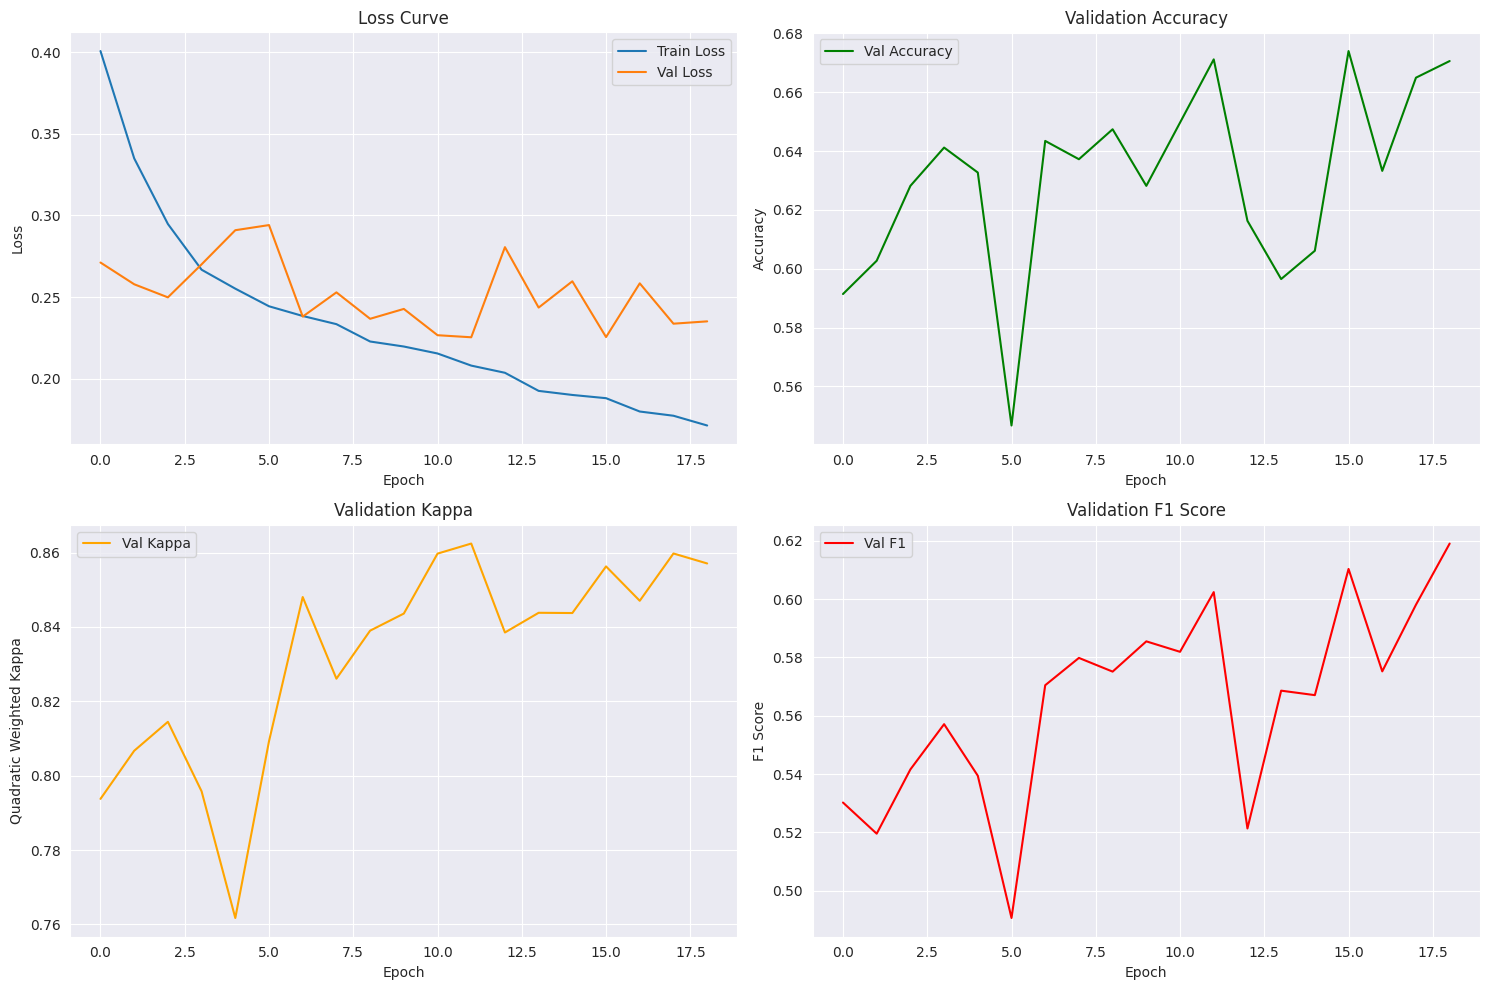

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Evaluating on test set...



Testing: 100%|██████████| 530/530 [01:21<00:00,  6.47it/s]



TEST SET RESULTS
Accuracy: 66.92%
Quadratic Weighted Kappa: 0.8511
Macro F1 Score: 0.5994

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.8571    0.9124    0.8839       434
      ISUP 1     0.6898    0.7950    0.7387       400
      ISUP 2     0.4410    0.4300    0.4354       200
      ISUP 3     0.4722    0.3676    0.4134       185
      ISUP 4     0.5233    0.4813    0.5014       187
      ISUP 5     0.6795    0.5761    0.6235       184

    accuracy                         0.6692      1590
   macro avg     0.6105    0.5937    0.5994      1590
weighted avg     0.6581    0.6692    0.6611      1590


Confusion Matrix:
[[396  32   3   2   1   0]
 [ 39 318  35   7   1   0]
 [  4  82  86  20   6   2]
 [  6  16  51  68  30  14]
 [ 10   9  15  29  90  34]
 [  7   4   5  18  44 106]]


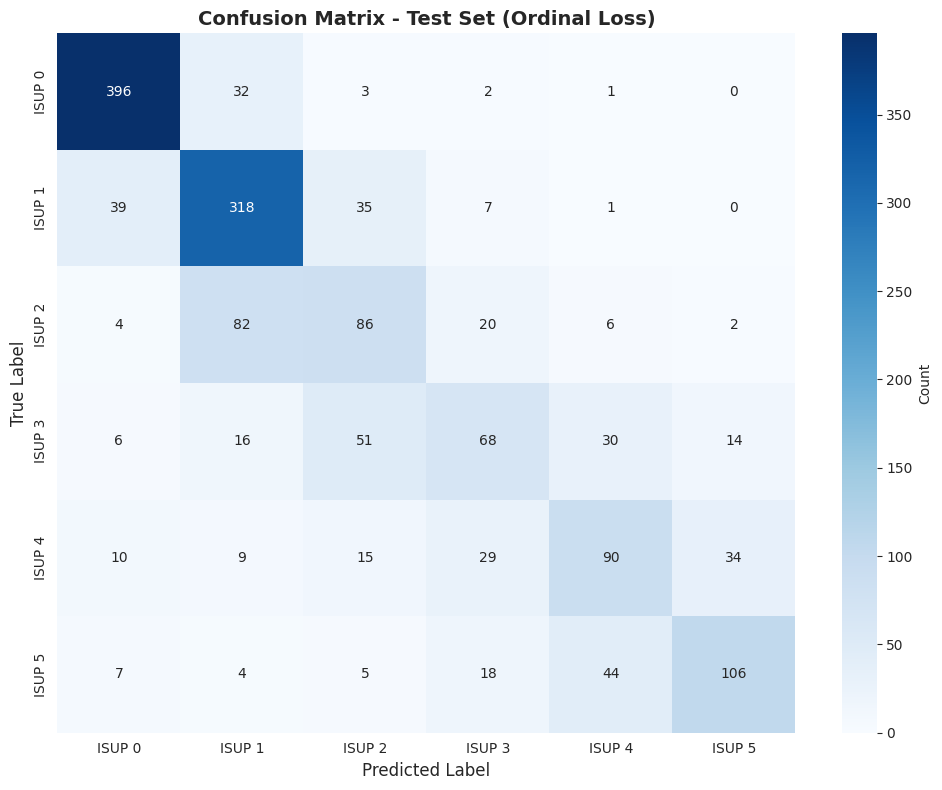


Test results saved to logs/b0-entropy-ordinal-test-results.txt


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print("TEST SET RESULTS")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Ordinal Loss)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('../logs/b0-entropy-ordinal-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0 with Entropy Filtering and Ordinal Loss\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-test-results.txt")

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalização por linha (cada linha soma 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels das classes (ajuste conforme necessário)
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Matriz de Confusão Normalizada")
plt.ylabel("Classe Verdadeira")
plt.xlabel("Classe Prevista")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'cm' is not defined

## Summary

This notebook trained EfficientNet-B0 with:
1. **Entropy filtering** - Removed high-entropy samples for cleaner training data
2. **Ordinal loss** - Leveraged the ordered nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)

The ordinal approach enforces the constraint that predictions should respect the natural ordering of grades, potentially improving performance on ordinal classification tasks like cancer grading.